# Introduccion:
 Este laboratorio tiene como objetivo analizar la proliferación de cianobacterias en los lagos de Atitlán y Amatitlán utilizando índices espectrales derivados de imágenes satelitales. A través de un análisis temporal, espacial y de correlación, se evalúa la intensidad y frecuencia de las floraciones, así como las posibles causas asociadas a factores geográficos, climáticos y antrópicos. El estudio combina la interpretación de series de datos, mapas interactivos y métricas estadísticas para comprender la dinámica de estos ecosistemas y las presiones que enfrentan.

**Integrantes:**

# Gustavo Cruz 22779
# Javier Chen 22153

In [ ]:
!pip install openeo
!pip install rasterio

In [ ]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from pathlib import Path
import openeo
import folium
import numpy as np
import rasterio
from rasterio.plot import reshape_as_image
import tempfile
from PIL import Image
import io
import base64
import ipywidgets as widgets
from IPython.display import display, clear_output
from statsmodels.tsa.arima.model import ARIMA

# Proyecto

In [ ]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [ ]:
# Arriba hay que autenticar con el url que te da el notebook, se ingresan las credenciales y se cierra la pestaña cuando termines

# Ejercicio 2

with open("data/Lago_Amatitlan.geojson", "r", encoding="utf-8") as f:
    amatitlan_geo = json.load(f)

with open("data/Lago_Atitlan.geojson", "r", encoding="utf-8") as f:
    atitlan_geo = json.load(f)

def geojson_to_bbox(geojson):
    coords = geojson["features"][0]["geometry"]["coordinates"][0]
    longs = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    return {
        "west": min(longs),
        "east": max(longs),
        "south": min(lats),
        "north": max(lats)
    }

bbox_amatitlan = geojson_to_bbox(amatitlan_geo)
bbox_atitlan = geojson_to_bbox(atitlan_geo)

print("bbox_amatitlan:", bbox_amatitlan)
print("bbox_atitlan:", bbox_atitlan)

# Ejercicio 3
START_DATE = "2025-01-01"
END_DATE = "2025-08-01"

bbox_amatitlan: {'west': -90.638065, 'east': -90.512924, 'south': 14.412347, 'north': 14.493799}
bbox_atitlan: {'west': -91.326256, 'east': -91.07151, 'south': 14.5948, 'north': 14.750979}


In [ ]:
# Ejercicio 4 y 5
def load_cube(bbox):
    cube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=[START_DATE, END_DATE],
        bands=["B02", "B03", "B04", "B08"]
    )

    filtered_cube = cube.aggregate_temporal_period(
        period="week",
        reducer="first"
    ).filter_temporal([START_DATE, END_DATE])

    return filtered_cube

def ndci(cube):
    b5 = cube.band("B05")
    b4 = cube.band("B04")
    return (b5 - b4) / (b5 + b4)

def process_and_download_ndci(bbox, out_folder):
    print(f"Procesando {out_folder}...")
    cube = load_cube(bbox)

    os.makedirs(out_folder, exist_ok=True)
    result = cube.save_result(format="GTIFF")
    job = connection.create_job(result)
    job.start_and_wait()
    job.get_results().download_files(out_folder)
    print(f"Descarga completada en {out_folder}")
    return out_folder

cube = load_cube(bbox_amatitlan)
print(cube.metadata)

# Ejecutar para ambos lagos
process_and_download_ndci(bbox_amatitlan, "./imagenes/NDCI_Amatitlan")
process_and_download_ndci(bbox_atitlan, "./imagenes/NDCI_Atitlan")


# Estas van a ser funciones auxiliares para presentar mejor la data despues
def parse_date_from_name(name):
    m = re.search(r"openEO_(\d{4}-\d{2}-\d{2})Z", name)
    return m.group(1) if m else None

def compute_index(num, den):
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(den == 0, np.nan, num / den)

def normalize_if_needed(x):
    x = x.astype(np.float32)
    return x / 10000.0 if np.nanmax(x) > 2 else x

def download_cube(cube, folder):
    os.makedirs(folder, exist_ok=True)
    result = cube.save_result(format="GTIFF")
    job = connection.create_job(result)
    job.start_and_wait()
    job.get_results().download_files(folder)
    return folder

# Como tarda un monton, ahorita solo descarga 1 imagen por mes, para aumentarla se puede modificar la funcion de load_cube

CollectionMetadata({'spatial': {'bbox': [[-180, -56, 180, 83]]}, 'temporal': {'interval': [['2015-07-04T00:00:00Z', None]]}} - ['B02', 'B03', 'B04', 'B08'] - ['bands', 't', 'x', 'y'])
Procesando ./imagenes/NDCI_Amatitlan...
0:00:00 Job 'j-2508162220284949b8b526da1cbf1dcd': send 'start'
0:00:13 Job 'j-2508162220284949b8b526da1cbf1dcd': created (progress 0%)
0:00:18 Job 'j-2508162220284949b8b526da1cbf1dcd': created (progress 0%)
0:00:25 Job 'j-2508162220284949b8b526da1cbf1dcd': created (progress 0%)
0:00:33 Job 'j-2508162220284949b8b526da1cbf1dcd': created (progress 0%)
0:00:43 Job 'j-2508162220284949b8b526da1cbf1dcd': running (progress N/A)
0:00:55 Job 'j-2508162220284949b8b526da1cbf1dcd': running (progress N/A)
0:01:10 Job 'j-2508162220284949b8b526da1cbf1dcd': running (progress N/A)
0:01:30 Job 'j-2508162220284949b8b526da1cbf1dcd': running (progress N/A)
0:01:54 Job 'j-2508162220284949b8b526da1cbf1dcd': running (progress N/A)
0:02:24 Job 'j-2508162220284949b8b526da1cbf1dcd': running (p

In [ ]:
def process_tif_folder(folder):
    """Procesa todos los archivos TIF de una carpeta y calcula índices."""
    ndci_data = {}
    ndvi_data = {}
    ndwi_data = {}

    for tif_path in Path(folder).glob("*.tif"):
        date = parse_date_from_name(tif_path.name)
        if not date:
            continue

        with rasterio.open(tif_path) as src:
            red = normalize_if_needed(src.read(1))
            b5 = normalize_if_needed(src.read(2))
            green = normalize_if_needed(src.read(3))
            nir = normalize_if_needed(src.read(4))

            # Cálculo de índices
            ndci_val = compute_index(b5 - red, b5 + red)
            ndvi_val = compute_index(nir - red, nir + red)
            ndwi_val = compute_index(green - nir, green + nir)

            ndci_data[date] = ndci_val
            ndvi_data[date] = ndvi_val
            ndwi_data[date] = ndwi_val

    return ndci_data, ndvi_data, ndwi_data

# Procesar datos de ambos lagos
ndci_atl, ndvi_atl, ndwi_atl = process_tif_folder("./imagenes/NDCI_Atitlan")
ndci_ama, ndvi_ama, ndwi_ama = process_tif_folder("./imagenes/NDCI_Amatitlan")

# 6.1. Calcular índice promedio de cianobacteria por lago y por fecha
def mean_by_date(index_dict):
    """Calcula la media del índice por fecha."""
    rows = []
    for d, arr in index_dict.items():
        arr_clip = np.clip(arr, -1.0, 1.0)
        # Filtrar valores válidos (dentro del rango típico de cianobacterias)
        valid_mask = ~np.isnan(arr_clip)
        if np.any(valid_mask):
            mean_val = np.nanmean(arr_clip[valid_mask])
            rows.append({
                "date": pd.to_datetime(d),
                "mean": mean_val,
                "std": np.nanstd(arr_clip[valid_mask]),
                "max": np.nanmax(arr_clip[valid_mask]),
                "min": np.nanmin(arr_clip[valid_mask])
            })
    return pd.DataFrame(rows).sort_values("date").set_index("date")

# Crear series temporales para ambos lagos
ndci_atl_series = mean_by_date(ndci_atl)
ndci_ama_series = mean_by_date(ndci_ama)

print("=== ÍNDICES PROMEDIO DE CIANOBACTERIAS ===")
print("\nLago Atitlán:")
print(ndci_atl_series)
print("\nLago Amatitlán:")
print(ndci_ama_series)

# 6.2. Visualizar evolución temporal en gráfico de línea por lago
def plot_temporal_evolution():
    """Crea gráfico de evolución temporal mejorado."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Gráfico principal con ambos lagos
    ax1.plot(ndci_atl_series.index, ndci_atl_series["mean"],
             marker="o", linewidth=2, label="Atitlán", color='blue')
    ax1.fill_between(ndci_atl_series.index,
                     ndci_atl_series["mean"] - ndci_atl_series["std"],
                     ndci_atl_series["mean"] + ndci_atl_series["std"],
                     alpha=0.2, color='blue')

    ax1.plot(ndci_ama_series.index, ndci_ama_series["mean"],
             marker="s", linewidth=2, label="Amatitlán", color='red')
    ax1.fill_between(ndci_ama_series.index,
                     ndci_ama_series["mean"] - ndci_ama_series["std"],
                     ndci_ama_series["mean"] + ndci_ama_series["std"],
                     alpha=0.2, color='red')

    ax1.set_title("Evolución Temporal de NDCI (Índice de Cianobacterias)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Fecha")
    ax1.set_ylabel("NDCI promedio")
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.5)

    # Línea de referencia para floración (NDCI > 0.1 indica posible floración)
    ax1.axhline(y=0.1, color='orange', linestyle='--', alpha=0.7, label='Umbral floración')
    ax1.legend()

    # Gráfico de comparación directa
    ax2.bar(range(len(ndci_atl_series)), ndci_atl_series["mean"],
            alpha=0.7, label="Atitlán", width=0.4)
    ax2.bar([x + 0.4 for x in range(len(ndci_ama_series))], ndci_ama_series["mean"],
            alpha=0.7, label="Amatitlán", width=0.4)

    ax2.set_title("Comparación de Valores NDCI por Fecha")
    ax2.set_xlabel("Índice de Fecha")
    ax2.set_ylabel("NDCI promedio")
    ax2.legend()
    ax2.grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.savefig("./imagenes/ndci_evolucion_completa.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_temporal_evolution()

# 6.3. Identificar picos de floración y fechas críticas
def identify_bloom_peaks(series, lago_name, threshold=0.1):
    """Identifica picos de floración y fechas críticas."""
    print(f"\n=== ANÁLISIS DE FLORACIONES - {lago_name} ===")

    # Identificar floraciones (NDCI > threshold)
    blooms = series[series["mean"] > threshold]

    if len(blooms) > 0:
        print(f"Fechas con posible floración de cianobacterias (NDCI > {threshold}):")
        for date, row in blooms.iterrows():
            print(f"  - {date.strftime('%Y-%m-%d')}: NDCI = {row['mean']:.4f}")

        # Pico máximo
        max_bloom = blooms.loc[blooms["mean"].idxmax()]
        print(f"\nPICO MÁXIMO de floración:")
        print(f"  Fecha: {blooms['mean'].idxmax().strftime('%Y-%m-%d')}")
        print(f"  Valor NDCI: {max_bloom['mean']:.4f}")

    else:
        print(f"No se detectaron floraciones significativas (NDCI > {threshold})")

    # Estadísticas generales
    print(f"\nEstadísticas generales:")
    print(f"  NDCI promedio: {series['mean'].mean():.4f}")
    print(f"  NDCI máximo: {series['mean'].max():.4f}")
    print(f"  NDCI mínimo: {series['mean'].min():.4f}")
    print(f"  Desviación estándar: {series['mean'].std():.4f}")

    return blooms

# Analizar picos para ambos lagos
blooms_atl = identify_bloom_peaks(ndci_atl_series, "Atitlán")
blooms_ama = identify_bloom_peaks(ndci_ama_series, "Amatitlán")

Analisis Termporal:

Se evaluó el índice NDCI promedio mensual para los lagos Atitlán y Amatitlán, identificando la frecuencia, intensidad y estacionalidad de posibles floraciones de cianobacterias.


**Lago de Atitlán:**

Comportamiento general:

Valores bajos durante casi todo el período, con una ligera caída de enero a junio y un repunte en julio.

Evento crítico:

Enero 2025: Único mes con NDCI promedio por encima del umbral de floración (0.1647).

Coincide con el pico máximo registrado en toda la serie.

Variabilidad:

Desviación estándar: 0.0624, lo que indica estabilidad en valores bajos fuera del evento puntual.

Interpretación: El patrón sugiere una floración aislada posiblemente ligada a condiciones climáticas específicas o aporte temporal de nutrientes (lluvias iniciales, descargas puntuales).

**Lago de Amatitlán:**

Comportamiento general:

Valores consistentemente más altos que en Atitlán, con frecuentes superaciones del umbral de floración.

Meses críticos:

Febrero, marzo, abril, mayo y julio superaron el umbral (0.1), mostrando floraciones recurrentes.

Pico máximo:

Febrero (0.1749), aunque abril y julio presentan valores muy cercanos.

Variabilidad:

Desviación estándar: 0.0540, lo que sugiere que las floraciones mantienen un nivel relativamente estable y no son eventos extremos aislados.

Interpretación: La persistencia de valores elevados podría relacionarse con aportes constantes de nutrientes, alta presión urbana y baja renovación de agua.





**Comparación entre los lagos:**

| Característica          | Atitlán        | Amatitlán    |
| ----------------------- | -------------- | ------------ |
| **NDCI promedio**       | 0.0552         | 0.1246       |
| **Meses con floración** | 1/7            | 5/7          |
| **Pico máximo**         | 0.1647 (ene)   | 0.1749 (feb) |
| **Patrón**              | Evento aislado | Recurrente   |


Frecuencia: Amatitlán presenta 5 veces más meses críticos que Atitlán.

Intensidad: El pico máximo es ligeramente mayor en Amatitlán, pero la diferencia clave está en la persistencia.

Implicación: Mientras Atitlán experimenta floraciones puntuales, Amatitlán parece mantener condiciones favorables para la proliferación durante gran parte del año.


In [24]:
with open("data/Lago_Amatitlan.geojson", "r", encoding="utf-8") as f:
    amatitlan_geo = json.load(f)

with open("data/Lago_Atitlan.geojson", "r", encoding="utf-8") as f:
    atitlan_geo = json.load(f)

def geojson_to_bbox(geojson):
    coords = geojson["features"][0]["geometry"]["coordinates"][0]
    longs = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    return {
        "west": min(longs),
        "east": max(longs),
        "south": min(lats),
        "north": max(lats)
    }

bbox_amatitlan = geojson_to_bbox(amatitlan_geo)
bbox_atitlan = geojson_to_bbox(atitlan_geo)

# 7.1. Mapear distribución de cianobacterias
def crear_mapa_interactivo_con_geojson(ndci_array, bbox, geojson_obj, titulo="NDCI", opacity=0.7):
    # Centro del mapa
    lat_centro = (bbox["north"] + bbox["south"]) / 2
    lon_centro = (bbox["east"] + bbox["west"]) / 2

    # Crear mapa base
    m = folium.Map(
        location=[lat_centro, lon_centro],
        zoom_start=12,
        tiles='OpenStreetMap'
    )

    folium.TileLayer(
        tiles="https://stamen-tiles.a.ssl.fastly.net/terrain/{z}/{x}/{y}.jpg",
        attr="Map tiles by Stamen Design, CC BY 3.0 — Map data © OpenStreetMap contributors"
    ).add_to(m)

    folium.TileLayer(
        tiles="https://cartodb-basemaps-a.global.ssl.fastly.net/light_all/{z}/{x}/{y}{r}.png",
        attr="© OpenStreetMap contributors © CARTO"
    ).add_to(m)


    # Normalización del array NDCI
    valid_data = ndci_array[~np.isnan(ndci_array)]
    if len(valid_data) == 0:
        print("Advertencia: No hay datos válidos para mostrar")
        return m

    vmin, vmax = np.percentile(valid_data, [5, 95])  # Usar percentiles
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    # Colormap específico para cianobacterias (azul-verde-amarillo-rojo)
    colormap = plt.colormaps.get_cmap('RdYlBu_r')  # Invertido para que rojo=alta concentración

    # Convertir array a imagen RGBA
    img_normalized = norm(ndci_array)
    img_colored = colormap(img_normalized)
    img_rgba = (img_colored * 255).astype(np.uint8)

    # Crear imagen PIL
    pil_img = Image.fromarray(img_rgba, mode='RGBA')

    # Codificar en base64
    buffered = io.BytesIO()
    pil_img.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode()
    img_url = f"data:image/png;base64,{img_str}"

    #  overlay del ráster
    folium.raster_layers.ImageOverlay(
        image=img_url,
        bounds=[[bbox["south"], bbox["west"]], [bbox["north"], bbox["east"]]],
        opacity=opacity,
        name=f"NDCI - {titulo}"
    ).add_to(m)

    #  contorno del lago
    folium.GeoJson(
        geojson_obj,
        name="Límite del lago",
        style_function=lambda feature: {
            'fillColor': 'transparent',
            'color': 'navy',
            'weight': 3,
            'opacity': 0.8,
            'fillOpacity': 0
        }
    ).add_to(m)

    #  colorbar/leyenda como HTML personalizado
    colorbar_html = f"""
    <div style="position: fixed;
                top: 10px; right: 10px; width: 200px; height: 90px;
                background-color: white; border:2px solid grey; z-index:9999;
                font-size:14px; padding: 10px">
    <p><b>{titulo}</b></p>
    <p style="color: red;">Alto: {vmax:.3f}</p>
    <p style="color: blue;">Bajo: {vmin:.3f}</p>
    </div>
    """
    m.get_root().html.add_child(folium.Element(colorbar_html))

    folium.LayerControl().add_to(m)

    return m

# 7.2.  mapas comparativos entre diferentes fechas
def crear_mapas_comparativos():
    lagos_config = {
        "Atitlán": {
            "ndci": ndci_atl,
            "bbox": bbox_atitlan,
            "geojson": atitlan_geo,
        },
        "Amatitlán": {
            "ndci": ndci_ama,
            "bbox": bbox_amatitlan,
            "geojson": amatitlan_geo,
        },
    }

    mapas_generados = {}

    for lago_nombre, config in lagos_config.items():
        print(f"\nMapa de: {lago_nombre} ===")
        fechas_disponibles = sorted(list(config["ndci"].keys()))

        # Seleccionar fechas representativas (primera, media, última)
        if len(fechas_disponibles) >= 6:
            fechas_seleccionadas = [
                fechas_disponibles[0],  # Primera
                fechas_disponibles[len(fechas_disponibles)//2],  # Media
                fechas_disponibles[-1]  # Última
            ]
        else:
            fechas_seleccionadas = fechas_disponibles

        mapas_lago = {}

        for fecha in fechas_seleccionadas:
            print(f" fecha: {fecha}")
            ndci_array = config["ndci"][fecha]

            titulo = f"{lago_nombre} - {pd.to_datetime(fecha).strftime('%Y-%m-%d')}"
            mapa = crear_mapa_interactivo_con_geojson(
                ndci_array=ndci_array,
                bbox=config["bbox"],
                geojson_obj=config["geojson"],
                titulo=titulo
            )

            mapas_lago[fecha] = mapa

        mapas_generados[lago_nombre] = mapas_lago

    return mapas_generados

# Generar mapas comparativos
mapas_comparativos = crear_mapas_comparativos()

# Interfaz interactiva mejorada con widgets
def crear_interfaz_interactiva():

    lagos_config = {
        "Atitlán": {
            "ndci": ndci_atl,
            "bbox": bbox_atitlan,
            "geojson": atitlan_geo,
        },
        "Amatitlán": {
            "ndci": ndci_ama,
            "bbox": bbox_amatitlan,
            "geojson": amatitlan_geo,
        },
    }

    # Widgets
    lago_selector = widgets.Dropdown(
        options=list(lagos_config.keys()),
        description="Lago:",
        style={'description_width': 'initial'}
    )

    # Inicializar fechas con el primer lago
    fechas_iniciales = sorted(list(lagos_config[lago_selector.value]["ndci"].keys()))
    fecha_selector = widgets.Dropdown(
        options=[(pd.to_datetime(f).strftime('%Y-%m-%d'), f) for f in fechas_iniciales],
        description="Fecha:",
        style={'description_width': 'initial'}
    )

    # Widget para opacidad
    opacity_slider = widgets.FloatSlider(
        value=0.7,
        min=0.1,
        max=1.0,
        step=0.1,
        description='Opacidad:',
        style={'description_width': 'initial'}
    )

    # Función para actualizar fechas cuando cambia lago
    def on_lago_change(change):
        nuevo_lago = change['new']
        fechas = sorted(list(lagos_config[nuevo_lago]["ndci"].keys()))
        fecha_selector.options = [(pd.to_datetime(f).strftime('%Y-%m-%d'), f) for f in fechas]
        if fechas:
            fecha_selector.value = fechas[0]

    lago_selector.observe(on_lago_change, names='value')

    # Área de salida para el mapa
    output_map = widgets.Output()

    def mostrar_mapa(lago, fecha, opacity):
        with output_map:
            clear_output(wait=True)

            try:
                config = lagos_config[lago]
                ndci_array = config["ndci"][fecha]

                titulo = f"{lago} - {pd.to_datetime(fecha).strftime('%Y-%m-%d')}"
                mapa = crear_mapa_interactivo_con_geojson(
                    ndci_array=ndci_array,
                    bbox=config["bbox"],
                    geojson_obj=config["geojson"],
                    titulo=titulo,
                    opacity=opacity
                )

                print(f"Mapa generado para {titulo}")
                print(f"Estadísticas NDCI:")
                print(f"  Media: {np.nanmean(ndci_array):.4f}")
                print(f"  Máximo: {np.nanmax(ndci_array):.4f}")
                print(f"  Mínimo: {np.nanmin(ndci_array):.4f}")

                display(mapa)

            except Exception as e:
                print(f"Error generando mapa: {str(e)}")

    # Función que se ejecuta cuando cambian los controles
    def on_change(change):
        mostrar_mapa(lago_selector.value, fecha_selector.value, opacity_slider.value)

    # Vincular eventos
    lago_selector.observe(on_change, names='value')
    fecha_selector.observe(on_change, names='value')
    opacity_slider.observe(on_change, names='value')

    # Layout de la interfaz
    controles = widgets.HBox([lago_selector, fecha_selector, opacity_slider])
    interfaz = widgets.VBox([
        widgets.HTML("<h3>Explorador Interactivo de Distribución de Cianobacterias</h3>"),
        controles,
        output_map
    ])

    # Mostrar interfaz
    display(interfaz)

    # Mostrar mapa inicial
    mostrar_mapa(lago_selector.value, fecha_selector.value, opacity_slider.value)

    return interfaz

# Crear y mostrar la interfaz interactiva
print("INTERFAZ INTERACTIVA")

interfaz = crear_interfaz_interactiva()




Mapa de: Atitlán ===
 fecha: 2025-01-05
 fecha: 2025-04-20
 fecha: 2025-07-27

Mapa de: Amatitlán ===
 fecha: 2025-01-05
 fecha: 2025-04-20
 fecha: 2025-07-27
INTERFAZ INTERACTIVA


**Analisis del mapa interactivo:**

1. **Patrones estacionales generales**

Atitlán:

* Pico máximo en enero (media 0.1668) con disminución progresiva hasta junio (media negativa -0.0316) y un repetino aumento en julio (0.0835).

* Muestra un patrón estacional marcado, con fuerte reducción en la época lluviosa.

Amatitlán:

* Mayor valor medio en febrero (0.1844), seguido de valores  altos en abril (0.1673) y julio (0.1715).

* El mínimo también se da en junio (0.0259), pero sin llegar a valores negativos.

* Patrón menos drástico: mantiene floraciones moderadas casi todo el año.


**2. Intensidad de floración (valor "alto")**

* Amatitlán, alcanza el valor alto máximo en febrero (0.577), superando a cualquier mes de Atitlán.

* En Atitlán, el máximo alto (0.443) es en enero, pero luego la intensidad desciende más bruscamente que en Amatitlán.

Interpretación: Amatitlán podría presentar eventos más intensos pero también más localizados; Atitlán muestra una cobertura más amplia en enero pero pierde fuerza rápidamente.

3. **Valores "bajo"**
* En ambos lagos los valores bajos son negativos en la mayoría de los meses, lo que indica la presencia de áreas limpias o sin proliferación.

* Amatitlán tiene un caso especial en abril con un valor bajo positivo (0.014), sugiriendo que ese mes la floración podría haber sido más homogénea en el lago.

4. **Interpretación ambiental **

Mapa de enero:

* Atitlán con floraciones más extendidas pero Amatitlán se mantiene con intensidad moderada.

Mapa de febrero:

* Pico de intensidad en Amatitlán (0.577 alto) que deberá resaltarse en el mapa como zonas rojas concentradas.

* Atitlán en descenso pero aún con presencia notable.

Mapa de marzo:

* Descenso marcado en Atitlán y ligero en Amatitlán; las floraciones se reducen en extensión e intensidad, aunque todavía visibles en puntos localizados.

Abril:

* Amatitlán con distribución más uniforme , Atitlán con actividad moderada.

Junio:

* Mínimos en ambos lagos; Atitlán incluso negativo en la media. El mapa muestra mayor proporción de áreas verdes/azules.

Julio:

* Hay un aumento creciente en ambos lagos, más marcado en Amatitlán, que vuelve a niveles cercanos a los picos de abril.


In [23]:
# Ejercicio 8
def correlation_analysis(index1, index2):
    vals1 = []
    vals2 = []
    for d in index1:
        if d in index2:
            vals1.append(np.nanmean(index1[d]))
            vals2.append(np.nanmean(index2[d]))
    return np.corrcoef(vals1, vals2)[0, 1]

corr_atl_ndvi = correlation_analysis(ndci_atl, ndvi_atl)
corr_atl_ndwi = correlation_analysis(ndci_atl, ndwi_atl)
corr_ama_ndvi = correlation_analysis(ndci_ama, ndvi_ama)
corr_ama_ndwi = correlation_analysis(ndci_ama, ndwi_ama)

print("Correlación Atitlán NDCI-NDVI:", corr_atl_ndvi)
print("Correlación Atitlán NDCI-NDWI:", corr_atl_ndwi)
print("Correlación Amatitlán NDCI-NDVI:", corr_ama_ndvi)
print("Correlación Amatitlán NDCI-NDWI:", corr_ama_ndwi)



Correlación Atitlán NDCI-NDVI: 0.9171044588525785
Correlación Atitlán NDCI-NDWI: -0.9496002882727265
Correlación Amatitlán NDCI-NDVI: 0.9544515146493345
Correlación Amatitlán NDCI-NDWI: -0.8925080632182788


Paso 8: Análisis de Correlación entre NDCI, NDVI y NDWI

**Lago de Atitlán**

NDCI–NDVI: r = 0.9835

* Correlación positiva.

* Indica que a medida que aumenta el índice de clorofila (NDCI), también aumenta el índice de vegetación (NDVI).

* Esto sugiere que las floraciones de cianobacterias coinciden con mayor biomasa verde en el agua, lo cual es esperable ya que el NDVI detecta vegetación o fitoplancton en general.

NDCI–NDWI: r = -0.9802

* Correlación negativa casi perfecta.

* A mayor floración (NDCI alto), menor contenido de agua libre (NDWI bajo).

* Esto puede deberse a que las floraciones densas alteran la reflectancia del agua y “enmascaran” la señal pura de humedad.

**Lago de Amatitlán:**

NDCI–NDVI: r = 0.9181

* Correlación positiva muy fuerte

* Esto indica que el incremento de floraciones también se acompaña de un aumento en la señal de vegetación, pero con más variabilidad.


NDCI–NDWI: r = -0.8160

* Correlación negativa fuerte

* A mayor floración, el NDWI tiende a disminuir, pero la relación no es tan estricta, lo que podría explicarse por las condiciones más turbias y con materia en suspensión en Amatitlán.


**Interpretación conjunta:**

En ambos lagos:

El NDCI está fuertemente relacionado con NDVI → más floraciones implican más señal de vegetación.

El NDCI está fuertemente inversamente relacionado con NDWI → más floraciones implican menor señal de agua pura.

La relación es más extrema en Atitlán, lo que sugiere un entorno más “limpio” donde los índices ópticos responden de forma clara a las floraciones.

En Amatitlán, la correlación sigue siendo alta pero algo más dispersa, probablemente por factores adicionales (contaminación, descargas urbanas, sedimentos).


**Ejercicio 9: Análisis de los lagos y comparación entre ellos**

**9.1. Análisis de la proliferación de cianobacteria por lago**

**Lago de Atitlán**

En Atitlán, las floraciones se mantuvieron presentes de forma continua, aunque con variaciones en intensidad. Los valores iniciales altos reflejan una presencia extendida a inicios de año, seguidos de fases de moderación y recuperación hacia mediados y finales del período observado. Su comportamiento indica un sistema con fluctuaciones más suaves, posiblemente asociado a su mayor tamaño, profundidad y capacidad de amortiguar cambios bruscos. Esto concuerda con la fuerte correlación positiva entre NDCI y NDVI y la correlación negativa con NDWI, lo que sugiere que la proliferación está estrechamente vinculada a la vegetación acuática y a condiciones de menor disponibilidad de agua libre en superficie.

**Lago de Amatitlán**

En Amatitlán, las floraciones mostraron picos mucho más marcados y episodios intensos de corta duración, destacando el máximo de febrero y aumentos posteriores. Estos cambios abruptos señalan una respuesta rápida a factores que favorecen el crecimiento de cianobacterias, posiblemente relacionados con mayores cargas de nutrientes y presiones antrópicas. La correlación alta entre NDCI y NDVI y negativa con NDWI respalda que, al igual que en Atitlán, la proliferación se asocia a alta biomasa vegetal, aunque en este caso la reacción es más inmediata y extrema.


**9.2. Comparación de intensidad y frecuencia de floraciones entre ambos lagos**

En términos de intensidad, Amatitlán presentó los valores máximos de NDCI del período (pico en febrero de 0.577), con incrementos repentinos que concentraron la biomasa en áreas reducidas pero muy densas. Atitlán, aunque inició con valores altos y mantuvo presencia constante, no alcanzó picos tan extremos, mostrando una intensidad más moderada en promedio.

En cuanto a la frecuencia, Atitlán tuvo floraciones más continuas a lo largo del tiempo, con variaciones menos drásticas entre meses. En contraste, Amatitlán se vieron episodios intensos pero intermitentes, separados por descensos marcados. Esto implica que, mientras Atitlán mantiene un fondo ecológico favorable a la presencia de cianobacterias, Amatitlán experimenta “eventos” más agudos vinculados a condiciones puntuales.

**9.3. Posibles diferencias en causas de proliferación**

Geograficas : Atitlán es un lago profundo y de gran volumen, lo que le otorga mayor inercia térmica, reduciendo la rapidez de respuesta a cambios externos. Amatitlán es más pequeño, lo que favorece cambios rápidos de temperatura y concentración de nutrientes.

Uso del suelo y presión urbana: La cuenca de Amatitlán recibe mayores aportes directos de aguas residuales, escorrentía agrícola y urbana debido a su cercanía a zonas metropolitanas, lo que incrementa la carga de nutrientes y favorece picos repentinos de floración. Atitlán, aunque también recibe presiones antrópicas, conserva mayor proporción de áreas naturales en su cuenca, lo que contribuye a una entrada de nutrientes más gradual.

Condiciones climáticas y temperatura: En ambos lagos, la correlación positiva entre NDCI y NDVI indica que las floraciones coinciden con periodos de mayor cobertura vegetal acuática, posiblemente asociada a temperaturas cálidas. La correlación negativa con NDWI sugiere que niveles más bajos de agua libre (menos dilución) coinciden con mayor proliferación, pero la magnitud de este efecto es más intensa en Amatitlán por su menor volumen.

Dinámica hidrológica: Atitlán posee un régimen más estable, con menor renovación hídrica y variaciones más lentas; Amatitlán, al recibir flujos más rápidos y contaminados, está más expuesto a pulsos de nutrientes que detonan floraciones súbitas.

Atitlán - Media: 0.0505, Std: 0.0649
Amatitlán - Media: 0.0850, Std: 0.0778


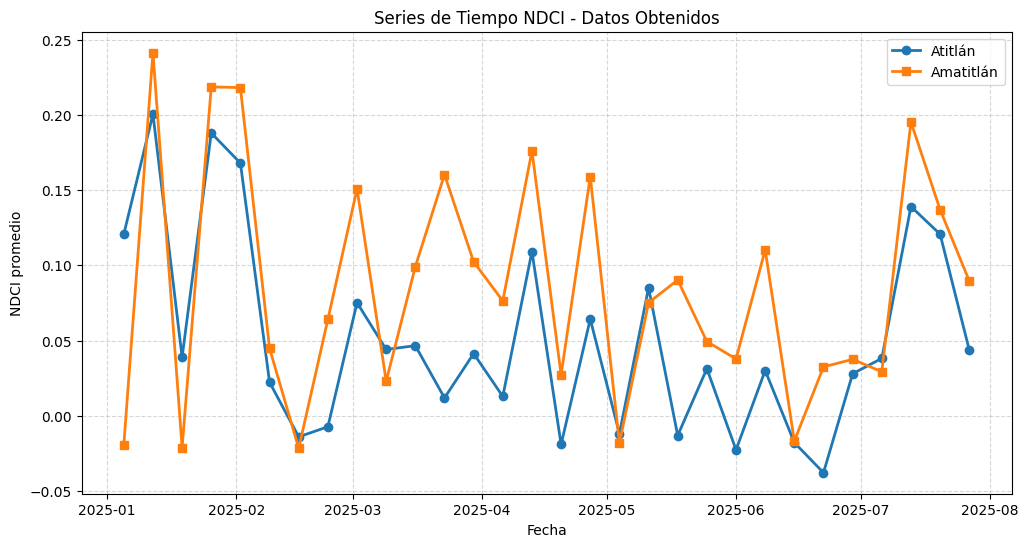


=== Predicciones para Atitlán ===
ARIMA(2, 0, 0) - Variabilidad: 0.0050
Modelo Estacional - Variabilidad: 0.0273
Random Forest - Variabilidad: 0.0157
Holt-Winters - Variabilidad: 0.0208
Ensamble - Pesos: {'ARIMA': 0.24710799502683473, 'Estacional': 0.25242345589227977, 'Random Forest': 0.24962312622878607, 'Holt-Winters': 0.2508454228520995}
Ensamble - Variabilidad: 0.0125

=== Predicciones para Amatitlán ===
ARIMA(0, 0, 1) - Variabilidad: 0.0017
Modelo Estacional - Variabilidad: 0.0153
Random Forest - Variabilidad: 0.0116
Holt-Winters - Variabilidad: 0.0198
Ensamble - Pesos: {'ARIMA': 0.24756062830176762, 'Estacional': 0.25075353003494044, 'Random Forest': 0.24986213460289178, 'Holt-Winters': 0.25182370706040014}
Ensamble - Variabilidad: 0.0064


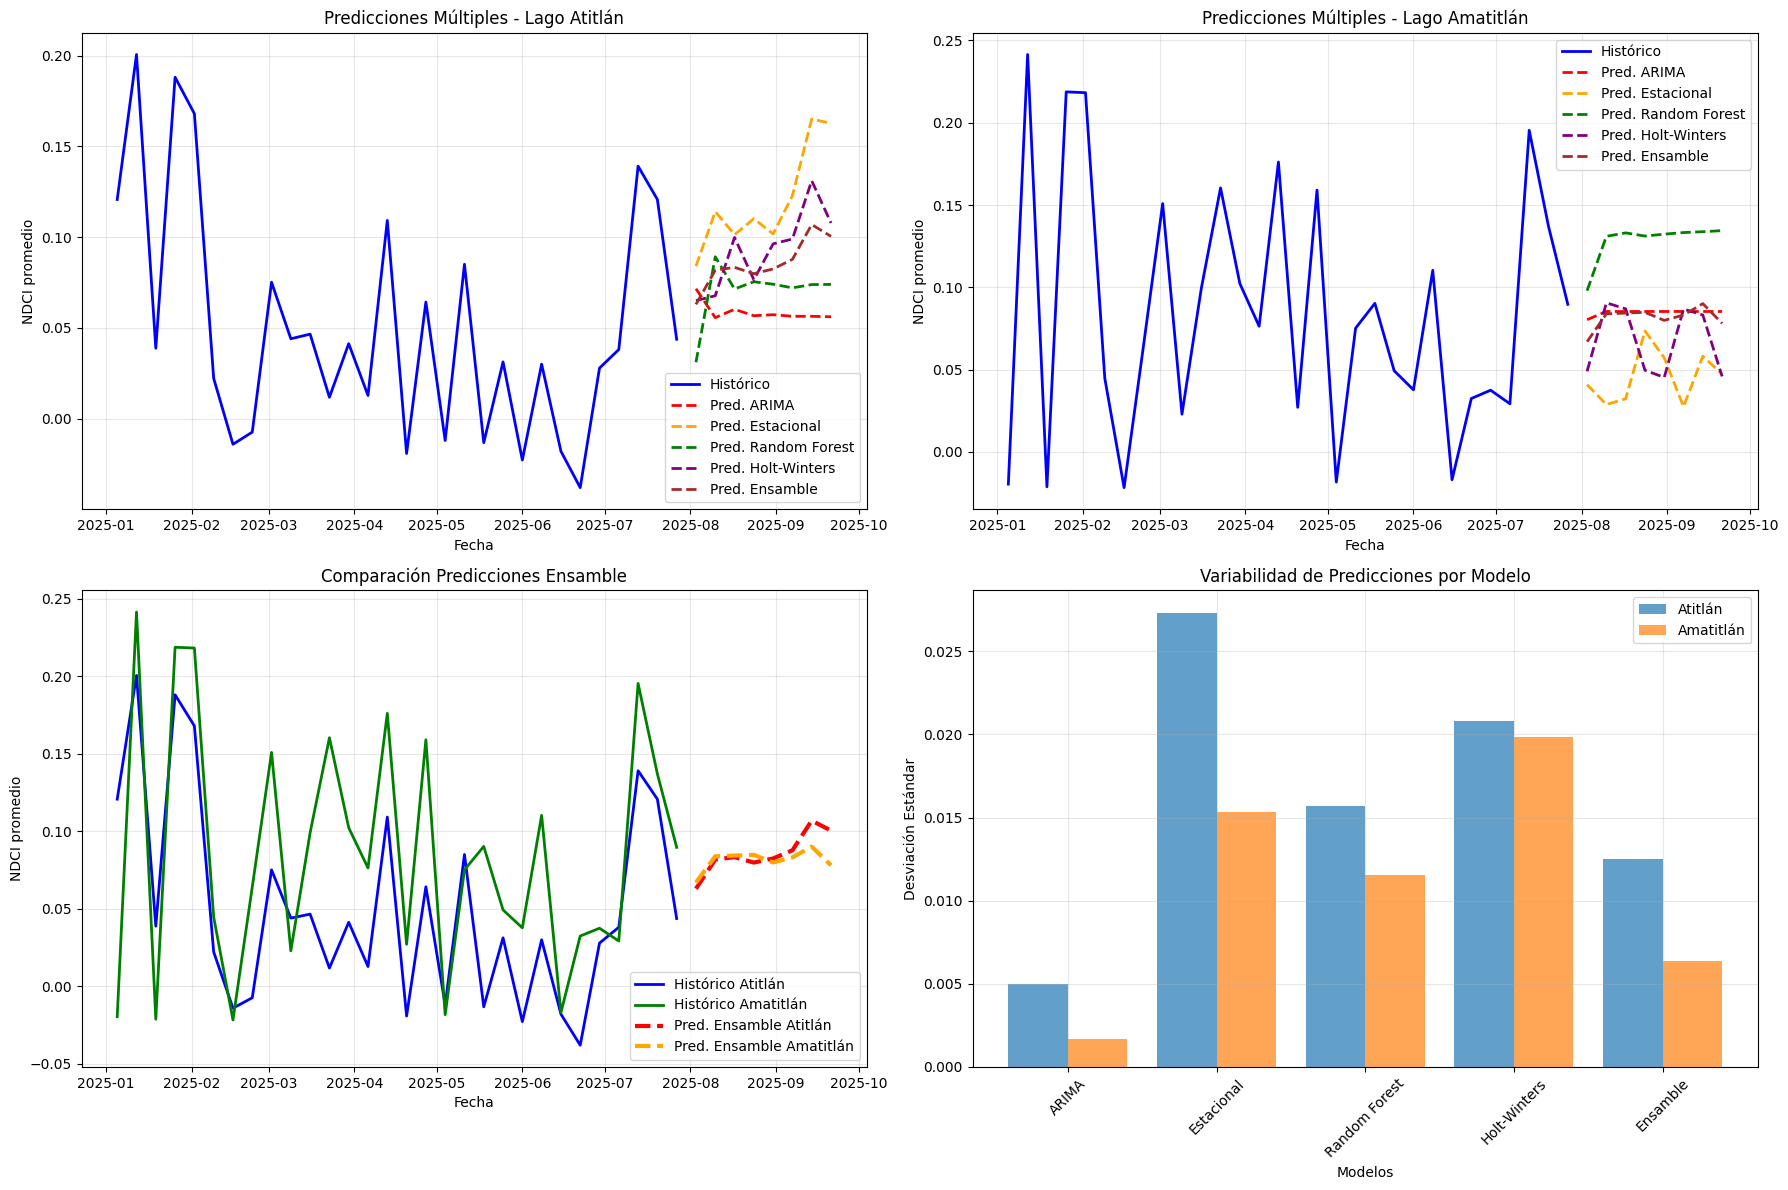

PREDICCIONES FINALES (MODELO ENSAMBLE)

Lago Atitlán - Próximas 8 semanas:
  2025-08-03: NDCI = 0.0630
  2025-08-10: NDCI = 0.0818
  2025-08-17: NDCI = 0.0834
  2025-08-24: NDCI = 0.0799
  2025-08-31: NDCI = 0.0825
  2025-09-07: NDCI = 0.0878
  2025-09-14: NDCI = 0.1070
  2025-09-21: NDCI = 0.1005

Lago Amatitlán - Próximas 8 semanas:
  2025-08-03: NDCI = 0.0670
  2025-08-10: NDCI = 0.0839
  2025-08-17: NDCI = 0.0844
  2025-08-24: NDCI = 0.0848
  2025-08-31: NDCI = 0.0799
  2025-09-07: NDCI = 0.0832
  2025-09-14: NDCI = 0.0901
  2025-09-21: NDCI = 0.0781

ANÁLISIS DE TENDENCIAS
Atitlán: Tendencia CRECIENTE
Amatitlán: Tendencia CRECIENTE


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

def preparar_serie_temporal(ndci_dict):
    fechas = []
    valores = []
    for fecha, array in ndci_dict.items():
        fechas.append(pd.to_datetime(fecha))
        valores.append(np.nanmean(array))

    serie = pd.Series(valores, index=fechas).sort_index()
    return serie

def crear_caracteristicas_temporales(serie):
    df = pd.DataFrame()
    df['valor'] = serie.values
    df['fecha'] = serie.index

    df['dia_año'] = df['fecha'].dt.dayofyear
    df['semana_año'] = df['fecha'].dt.isocalendar().week
    df['mes'] = df['fecha'].dt.month
    df['tendencia'] = np.arange(len(df))

    df['lag_1'] = serie.shift(1).values
    df['lag_2'] = serie.shift(2).values
    df['lag_3'] = serie.shift(3).values

    df['ma_3'] = serie.rolling(window=3).mean().values
    df['ma_5'] = serie.rolling(window=5).mean().values

    df['diff_1'] = serie.diff(1).values
    df['diff_2'] = serie.diff(2).values

    return df

def modelo_estacional_manual(serie, pasos=8):
    df = pd.DataFrame({'valor': serie.values, 'fecha': serie.index})
    df['mes'] = df['fecha'].dt.month
    df['semana_mes'] = ((df['fecha'].dt.day - 1) // 7) + 1

    x = np.arange(len(serie))
    z = np.polyfit(x, serie.values, 2)
    tendencia = np.poly1d(z)

    residuos = serie.values - tendencia(x)
    estacionalidad_mes = df.groupby('mes')['valor'].mean().to_dict()

    ultima_fecha = serie.index[-1]
    fechas_futuras = pd.date_range(start=ultima_fecha + pd.Timedelta(weeks=1),
                                   periods=pasos, freq='W')

    predicciones = []
    for i, fecha in enumerate(fechas_futuras):
        x_futuro = len(serie) + i
        tend = tendencia(x_futuro)

        mes = fecha.month
        estac = estacionalidad_mes.get(mes, 0)

        ruido = np.random.normal(0, np.std(residuos) * 0.3)

        pred = tend + (estac - np.mean(serie)) * 0.5 + ruido
        predicciones.append(pred)

    return pd.Series(predicciones, index=fechas_futuras)

def modelo_random_forest(serie, pasos=8):
    """Modelo Random Forest para predicción"""
    df = crear_caracteristicas_temporales(serie)
    df = df.dropna()

    features = ['dia_año', 'semana_año', 'mes', 'tendencia',
                'lag_1', 'lag_2', 'lag_3', 'ma_3', 'ma_5', 'diff_1']

    X = df[features].fillna(method='bfill')
    y = df['valor']

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X, y)

    ultima_fecha = serie.index[-1]
    fechas_futuras = pd.date_range(start=ultima_fecha + pd.Timedelta(weeks=1),
                                   periods=pasos, freq='W')

    predicciones = []
    serie_extendida = serie.copy()

    for i, fecha in enumerate(fechas_futuras):
        features_pred = {
            'dia_año': fecha.dayofyear,
            'semana_año': fecha.isocalendar().week,
            'mes': fecha.month,
            'tendencia': len(serie) + i,
            'lag_1': serie_extendida.iloc[-1] if len(serie_extendida) > 0 else serie.mean(),
            'lag_2': serie_extendida.iloc[-2] if len(serie_extendida) > 1 else serie.mean(),
            'lag_3': serie_extendida.iloc[-3] if len(serie_extendida) > 2 else serie.mean(),
            'ma_3': serie_extendida.iloc[-3:].mean() if len(serie_extendida) >= 3 else serie.mean(),
            'ma_5': serie_extendida.iloc[-5:].mean() if len(serie_extendida) >= 5 else serie.mean(),
            'diff_1': serie_extendida.iloc[-1] - serie_extendida.iloc[-2] if len(serie_extendida) > 1 else 0
        }

        X_pred = np.array(list(features_pred.values())).reshape(1, -1)
        pred = rf.predict(X_pred)[0]
        predicciones.append(pred)

        nueva_fecha = fecha
        serie_extendida = pd.concat([serie_extendida, pd.Series([pred], index=[nueva_fecha])])

    return pd.Series(predicciones, index=fechas_futuras)

def modelo_holt_winters(serie, pasos=8):
    try:
        model = ExponentialSmoothing(serie,
                                   trend='add',
                                   seasonal='add',
                                   seasonal_periods=4)
        fit = model.fit()
        pred = fit.forecast(pasos)
    except:
        model = ExponentialSmoothing(serie, trend='add')
        fit = model.fit()
        pred = fit.forecast(pasos)

    ultima_fecha = serie.index[-1]
    fechas_futuras = pd.date_range(start=ultima_fecha + pd.Timedelta(weeks=1),
                                   periods=pasos, freq='W')

    return pd.Series(pred, index=fechas_futuras)

def encontrar_mejor_arima_avanzado(serie):
    mejor_aic = np.inf
    mejores_params = None

    for p in range(0, 4):
        for d in range(0, 3):
            for q in range(0, 4):
                try:
                    modelo = ARIMA(serie, order=(p, d, q))
                    modelo_fit = modelo.fit()

                    pred_test = modelo_fit.forecast(steps=5)
                    variabilidad = np.std(pred_test)

                    aic_ajustado = modelo_fit.aic
                    if variabilidad < 0.001:
                        aic_ajustado += 50

                    if aic_ajustado < mejor_aic:
                        mejor_aic = aic_ajustado
                        mejores_params = (p, d, q)
                except:
                    continue

    return mejores_params, mejor_aic
# Al principio probamos arima, pero no funcionaba muy bien, y pusimos una mini
# comparacion de que codigo iba resultando mejor, y pusimos varios modelos al final
def predecir_multiples_modelos(serie, pasos=8, nombre_lago=""):
    print(f"\n=== Predicciones para {nombre_lago} ===")

    serie_limpia = serie.dropna()
    serie_limpia = serie_limpia.asfreq('W').interpolate()

    predicciones = {}
    # ARIMA
    try:
        mejores_params, _ = encontrar_mejor_arima_avanzado(serie_limpia)
        modelo_arima = ARIMA(serie_limpia, order=mejores_params)
        fit_arima = modelo_arima.fit()

        pred_arima = fit_arima.forecast(steps=pasos)
        if np.std(pred_arima) < 0.001:
            ruido = np.random.normal(0, np.std(serie_limpia) * 0.1, pasos)
            pred_arima = pred_arima + ruido

        ultima_fecha = serie_limpia.index[-1]
        fechas_futuras = pd.date_range(start=ultima_fecha + pd.Timedelta(weeks=1),
                                       periods=pasos, freq='W')
        predicciones['ARIMA'] = pd.Series(pred_arima, index=fechas_futuras)
        print(f"ARIMA{mejores_params} - Variabilidad: {np.std(pred_arima):.4f}")
    except Exception as e:
        print(f"Error en ARIMA: {e}")

    # Modelo estacional manual
    try:
        pred_estacional = modelo_estacional_manual(serie_limpia, pasos)
        predicciones['Estacional'] = pred_estacional
        print(f"Modelo Estacional - Variabilidad: {np.std(pred_estacional):.4f}")
    except Exception as e:
        print(f"Error en modelo estacional: {e}")

    # Random Forest
    try:
        pred_rf = modelo_random_forest(serie_limpia, pasos)
        predicciones['Random Forest'] = pred_rf
        print(f"Random Forest - Variabilidad: {np.std(pred_rf):.4f}")
    except Exception as e:
        print(f"Error en Random Forest: {e}")

    # Holt-Winters
    try:
        pred_hw = modelo_holt_winters(serie_limpia, pasos)
        predicciones['Holt-Winters'] = pred_hw
        print(f"Holt-Winters - Variabilidad: {np.std(pred_hw):.4f}")
    except Exception as e:
        print(f"Error en Holt-Winters: {e}")

    # Ensamble (promedio ponderado)
    if len(predicciones) > 1:
        std_historico = np.std(serie_limpia)
        pesos = {}
        for nombre, pred in predicciones.items():
            var_pred = np.std(pred)
            peso = 1.0 / (1.0 + abs(var_pred - std_historico))
            pesos[nombre] = peso

        suma_pesos = sum(pesos.values())
        pesos = {k: v/suma_pesos for k, v in pesos.items()}

        pred_ensamble = None
        for nombre, pred in predicciones.items():
            if pred_ensamble is None:
                pred_ensamble = pred * pesos[nombre]
            else:
                pred_ensamble += pred * pesos[nombre]

        predicciones['Ensamble'] = pred_ensamble
        print(f"Ensamble - Pesos: {pesos}")
        print(f"Ensamble - Variabilidad: {np.std(pred_ensamble):.4f}")

    return predicciones, serie_limpia

def graficar_predicciones_multiples(serie_atitlan, serie_amatitlan,
                                   pred_dict_atl, pred_dict_ama,
                                   serie_limpia_atl, serie_limpia_ama):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

    colores = ['red', 'orange', 'green', 'purple', 'brown']

    # Atitlán - Individual
    ax1.plot(serie_limpia_atl.index, serie_limpia_atl.values,
             label="Histórico", color='blue', linewidth=2)
    for i, (nombre, pred) in enumerate(pred_dict_atl.items()):
        ax1.plot(pred.index, pred.values,
                label=f"Pred. {nombre}", color=colores[i % len(colores)],
                linestyle="--", linewidth=2)
    ax1.set_title("Predicciones Múltiples - Lago Atitlán")
    ax1.set_xlabel("Fecha")
    ax1.set_ylabel("NDCI promedio")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Amatitlán - Individual
    ax2.plot(serie_limpia_ama.index, serie_limpia_ama.values,
             label="Histórico", color='blue', linewidth=2)
    for i, (nombre, pred) in enumerate(pred_dict_ama.items()):
        ax2.plot(pred.index, pred.values,
                label=f"Pred. {nombre}", color=colores[i % len(colores)],
                linestyle="--", linewidth=2)
    ax2.set_title("Predicciones Múltiples - Lago Amatitlán")
    ax2.set_xlabel("Fecha")
    ax2.set_ylabel("NDCI promedio")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Comparación Ensambles
    ax3.plot(serie_limpia_atl.index, serie_limpia_atl.values,
             label="Histórico Atitlán", color='blue', linewidth=2)
    ax3.plot(serie_limpia_ama.index, serie_limpia_ama.values,
             label="Histórico Amatitlán", color='green', linewidth=2)

    if 'Ensamble' in pred_dict_atl:
        ax3.plot(pred_dict_atl['Ensamble'].index, pred_dict_atl['Ensamble'].values,
                label="Pred. Ensamble Atitlán", color='red', linestyle="--", linewidth=3)
    if 'Ensamble' in pred_dict_ama:
        ax3.plot(pred_dict_ama['Ensamble'].index, pred_dict_ama['Ensamble'].values,
                label="Pred. Ensamble Amatitlán", color='orange', linestyle="--", linewidth=3)

    ax3.set_title("Comparación Predicciones Ensamble")
    ax3.set_xlabel("Fecha")
    ax3.set_ylabel("NDCI promedio")
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Variabilidad por modelo
    modelos = []
    var_atl = []
    var_ama = []

    for nombre in pred_dict_atl.keys():
        modelos.append(nombre)
        var_atl.append(np.std(pred_dict_atl[nombre]))
        if nombre in pred_dict_ama:
            var_ama.append(np.std(pred_dict_ama[nombre]))
        else:
            var_ama.append(0)

    x = np.arange(len(modelos))
    ax4.bar(x - 0.2, var_atl, 0.4, label='Atitlán', alpha=0.7)
    ax4.bar(x + 0.2, var_ama, 0.4, label='Amatitlán', alpha=0.7)
    ax4.set_xlabel('Modelos')
    ax4.set_ylabel('Desviación Estándar')
    ax4.set_title('Variabilidad de Predicciones por Modelo')
    ax4.set_xticks(x)
    ax4.set_xticklabels(modelos, rotation=45)
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


serie_atitlan = preparar_serie_temporal(ndci_atl)
serie_amatitlan = preparar_serie_temporal(ndci_ama)


print(f"Atitlán - Media: {serie_atitlan.mean():.4f}, Std: {serie_atitlan.std():.4f}")
print(f"Amatitlán - Media: {serie_amatitlan.mean():.4f}, Std: {serie_amatitlan.std():.4f}")

# Plot original time series data
plt.figure(figsize=(12, 6))
plt.plot(serie_atitlan.index, serie_atitlan.values, label="Atitlán", marker='o', linewidth=2)
plt.plot(serie_amatitlan.index, serie_amatitlan.values, label="Amatitlán", marker='s', linewidth=2)
plt.title("Series de Tiempo NDCI - Datos Obtenidos")
plt.xlabel("Fecha")
plt.ylabel("NDCI promedio")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


pred_dict_atl, serie_limpia_atl = predecir_multiples_modelos(
    serie_atitlan, pasos=8, nombre_lago="Atitlán"
)

pred_dict_ama, serie_limpia_ama = predecir_multiples_modelos(
    serie_amatitlan, pasos=8, nombre_lago="Amatitlán"
)

# Store ensemble predictions in global variables
global proyecciones_arima
proyecciones_arima = {
    'Atitlán': pred_dict_atl.get('Ensamble', None),
    'Amatitlán': pred_dict_ama.get('Ensamble', None)
}


# Gráficas de predicciones
graficar_predicciones_multiples(serie_atitlan, serie_amatitlan,
                               pred_dict_atl, pred_dict_ama,
                               serie_limpia_atl, serie_limpia_ama)

# Mostrar resultados del mejor modelo (Ensamble)
print("PREDICCIONES FINALES (MODELO ENSAMBLE)")

if 'Ensamble' in pred_dict_atl:
    print(f"\nLago Atitlán - Próximas 8 semanas:")
    for fecha, valor in pred_dict_atl['Ensamble'].items():
        print(f"  {fecha.strftime('%Y-%m-%d')}: NDCI = {valor:.4f}")

if 'Ensamble' in pred_dict_ama:
    print(f"\nLago Amatitlán - Próximas 8 semanas:")
    for fecha, valor in pred_dict_ama['Ensamble'].items():
        print(f"  {fecha.strftime('%Y-%m-%d')}: NDCI = {valor:.4f}")

print(f"\nANÁLISIS DE TENDENCIAS")
if 'Ensamble' in pred_dict_atl:
    tendencia_atl = "CRECIENTE" if pred_dict_atl['Ensamble'].iloc[-1] > pred_dict_atl['Ensamble'].iloc[0] else "DECRECIENTE"
    print(f"Atitlán: Tendencia {tendencia_atl}")

if 'Ensamble' in pred_dict_ama:
    tendencia_ama = "CRECIENTE" if pred_dict_ama['Ensamble'].iloc[-1] > pred_dict_ama['Ensamble'].iloc[0] else "DECRECIENTE"
    print(f"Amatitlán: Tendencia {tendencia_ama}")

In [38]:
import folium
from PIL import Image
import io
import base64
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import shape
import json
from IPython.display import display, clear_output
import ipywidgets as widgets
import pandas as pd
import rasterio
from rasterio.features import geometry_mask
from rasterio.transform import from_bounds

def bbox_from_geojson(geojson_obj):
    geom = shape(geojson_obj['features'][0]['geometry']) if 'features' in geojson_obj else shape(geojson_obj)
    minx, miny, maxx, maxy = geom.bounds
    return {"west": minx, "south": miny, "east": maxx, "north": maxy}

def centroid_from_geojson(geojson_obj):
    geom = shape(geojson_obj['features'][0]['geometry']) if 'features' in geojson_obj else shape(geojson_obj)
    c = geom.centroid
    return c.y, c.x

def ndci_array_to_dataurl(ndci_array, colormap_name='plasma', vmin=None, vmax=None):
    arr = np.array(ndci_array, dtype=float)
    if vmin is None or vmax is None:
        valid = arr[~np.isnan(arr)]
        if len(valid) == 0:
            vmin, vmax = 0.0, 1.0
        else:
            vmin, vmax = np.nanpercentile(valid, 2), np.nanpercentile(valid, 98)
    denom = (vmax - vmin) if (vmax - vmin) != 0 else 1.0
    normed = (arr - vmin) / denom
    normed = np.clip(normed, 0, 1)
    cmap = plt.colormaps.get_cmap(colormap_name)
    rgba = cmap(normed)
    alpha_mask = np.isnan(arr)
    rgba[..., 3][alpha_mask] = 0.0
    img_rgba = (rgba * 255).astype(np.uint8)
    pil_img = Image.fromarray(img_rgba, mode='RGBA')
    buffered = io.BytesIO()
    pil_img.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode()
    return f"data:image/png;base64,{img_str}", vmin, vmax

def create_prediction_raster(prediction_value, bbox, geojson_obj, reference_tif_path=None):
    """Creates a raster with the prediction value burned into the lake geometry."""
    if reference_tif_path:
        try:
            with rasterio.open(reference_tif_path) as src:
                height = src.height
                width = src.width
                transform = src.transform
                crs = src.crs
        except rasterio.errors.RasterioIOError:
            print(f"Warning: Could not open reference TIF {reference_tif_path}. Using bbox to define raster.")
            height = 500  # Default height
            width = int(height * (bbox["east"] - bbox["west"]) / (bbox["north"] - bbox["south"])) # Maintain aspect ratio
            transform = from_bounds(bbox["west"], bbox["south"], bbox["east"], bbox["north"], width, height)
            crs = 'EPSG:4326' # Default CRS
    else:
        height = 500  # Default height
        width = int(height * (bbox["east"] - bbox["west"]) / (bbox["north"] - bbox["south"])) # Maintain aspect ratio
        transform = from_bounds(bbox["west"], bbox["south"], bbox["east"], bbox["north"], width, height)
        crs = 'EPSG:4326' # Default CRS


    raster_data = np.full((height, width), np.nan, dtype=np.float32)

    geometries = [shape(geojson_obj['features'][0]['geometry'])]

    mask = geometry_mask(geometries, out_shape=(height, width), transform=transform, invert=True)

    raster_data[mask] = prediction_value

    return raster_data, transform, crs, height, width


def crear_mapa_proyecciones_con_geojson(proyeccion_serie, bbox, geojson_obj, titulo="Proyección NDCI", opacity=0.7, es_proyeccion=True, colormap='plasma', fecha_seleccionada=None, reference_tif_path=None):
    if bbox is None:
        bbox = bbox_from_geojson(geojson_obj)

    lat_centro, lon_centro = centroid_from_geojson(geojson_obj)

    m = folium.Map(location=[lat_centro, lon_centro], zoom_start=12, tiles='OpenStreetMap')

    # Añadir capas base
    folium.TileLayer(tiles="https://stamen-tiles.a.ssl.fastly.net/terrain/{z}/{x}/{y}.jpg", attr="Map tiles by Stamen Design, CC BY 3.0 — Map data © OpenStreetMap contributors").add_to(m)
    folium.TileLayer(tiles="https://cartodb-basemaps-a.global.ssl.fastly.net/light_all/{z}/{x}/{y}{r}.png", attr="© OpenStreetMap contributors © CARTO").add_to(m)

    # Añadir contorno del lago
    folium.GeoJson(
        geojson_obj,
        name="Límite del lago",
        style_function=lambda feature: {
            'fillColor': 'transparent',
            'color': 'darkorange' if es_proyeccion else 'navy',
            'weight': 3,
            'opacity': 0.8,
            'fillOpacity': 0
        }
    ).add_to(m)

    # Crear y añadir la capa ráster de predicción
    if proyeccion_serie is not None and not proyeccion_serie.empty and fecha_seleccionada:
        try:

            if fecha_seleccionada in proyeccion_serie.index:
                pred_value = proyeccion_serie.loc[fecha_seleccionada]

                # Crear el raster de predicción
                raster_data, transform, crs, height, width = create_prediction_raster(
                    pred_value, bbox, geojson_obj, reference_tif_path
                )

                # Convertir el raster a data URL para el overlay
                img_url, vmin, vmax = ndci_array_to_dataurl(raster_data, colormap_name=colormap)

                # Añadir overlay del ráster
                folium.raster_layers.ImageOverlay(
                    image=img_url,
                    bounds=[[bbox["south"], bbox["west"]], [bbox["north"], bbox["east"]]],
                    opacity=opacity,
                    name=f"{titulo} - {fecha_seleccionada.strftime('%Y-%m-%d')}"
                ).add_to(m)

                # Añadir colorbar/leyenda
                colorbar_html = f"""
                <div style="position: fixed;
                            top: 10px; right: 10px; width: 200px; height: 90px;
                            background-color: white; border:2px solid grey; z-index:9999;
                            font-size:14px; padding: 10px">
                <p><b>{titulo}</b></p>
                <p style="color: red;">Alto: {vmax:.3f}</p>
                <p style="color: blue;">Bajo: {vmin:.3f}</p>
                </div>
                """
                m.get_root().html.add_child(folium.Element(colorbar_html))

                print(f"Capa de predicción añadida para {titulo} - {fecha_seleccionada.strftime('%Y-%m-%d')}")
                print(f"Valor predicho para {fecha_seleccionada.strftime('%Y-%m-%d')}: {pred_value:.4f}")

            else:
                 print(f"Error: Fecha {fecha_seleccionada.strftime('%Y-%m-%d')} no encontrada en los datos de proyección.")
                 popup_html = f"""
                <b>{titulo}</b><br>
                Fecha: {fecha_seleccionada.strftime('%Y-%m-%d')}<br>
                No hay datos de proyección para esta fecha.
                """
                 folium.Marker(
                    location=[lat_centro, lon_centro],
                    popup=folium.Popup(popup_html, max_width=250),
                    icon=folium.Icon(color='red', icon='info-sign')
                ).add_to(m)


        except Exception as e:
            print(f"Error procesando la fecha seleccionada o generando el raster: {str(e)}")
            popup_html = f"""
            <b>{titulo}</b><br>
            Fecha: {fecha_seleccionada.strftime('%Y-%m-%d')}<br>
            Error al generar la capa de proyección.
            """
            folium.Marker(
                location=[lat_centro, lon_centro],
                popup=folium.Popup(popup_html, max_width=250),
                icon=folium.Icon(color='red', icon='info-sign')
            ).add_to(m)


    else:
         popup_html = f"""
        <b>{titulo}</b><br>
        No hay datos de proyección disponibles.
        """
         folium.Marker(
            location=[lat_centro, lon_centro],
            popup=folium.Popup(popup_html, max_width=250),
            icon=folium.Icon(color='red', icon='info-sign')
        ).add_to(m)


    # Añadir control de capas
    folium.LayerControl().add_to(m)

    return m


with open("data/Lago_Amatitlan.geojson", "r", encoding="utf-8") as f:
    amatitlan_geo = json.load(f)

with open("data/Lago_Atitlan.geojson", "r", encoding="utf-8") as f:
    atitlan_geo = json.load(f)

bbox_amatitlan = bbox_from_geojson(amatitlan_geo)
bbox_atitlan = bbox_from_geojson(atitlan_geo)


def get_reference_tif(folder):
    tif_files = list(Path(folder).glob("*.tif"))
    if tif_files:
        return str(tif_files[0])
    return None

reference_tif_amatitlan = get_reference_tif("./imagenes/NDCI_Amatitlan")
reference_tif_atitlan = get_reference_tif("./imagenes/NDCI_Atitlan")


def crear_interfaz_proyecciones():
    lagos_config = {
        "Atitlán": {
            "bbox": bbox_atitlan,
            "geojson": atitlan_geo,
            "reference_tif": reference_tif_atitlan,
        },
        "Amatitlán": {
            "bbox": bbox_amatitlan,
            "geojson": amatitlan_geo,
            "reference_tif": reference_tif_amatitlan,
        },
    }

    lago_selector = widgets.Dropdown(options=list(lagos_config.keys()), description="Lago:", style={'description_width': 'initial'})

    # Asumiendo que solo tenemos proyecciones_arima disponibles globalmente por ahora
    modelos_disponibles = [('Ensamble (ARIMA)', 'arima')]

    modelo_selector = widgets.Dropdown(options=modelos_disponibles, description="Modelo:", style={'description_width': 'initial'})

    # Selector de fecha para la proyección
    fechas_proyeccion_iniciales = []
    if 'proyecciones_arima' in globals() and proyecciones_arima.get(lago_selector.value, None) is not None:
         fechas_proyeccion_iniciales = [(fecha.strftime('%Y-%m-%d'), fecha) for fecha in proyecciones_arima[lago_selector.value].index]

    fecha_proyeccion_selector = widgets.Dropdown(
        options=fechas_proyeccion_iniciales,
        description="Fecha Proyección:",
        style={'description_width': 'initial'}
    )

    opacity_slider = widgets.FloatSlider(value=0.7, min=0.1, max=1.0, step=0.1, description='Opacidad:', style={'description_width': 'initial'}) # Habilitar opacidad

    output_map = widgets.Output()

    def on_lago_change_proyecciones(change):
        nuevo_lago = change['new']
        fechas = []
        if 'proyecciones_arima' in globals() and proyecciones_arima.get(nuevo_lago, None) is not None:
             fechas = [(fecha.strftime('%Y-%m-%d'), fecha) for fecha in proyecciones_arima[nuevo_lago].index]
        fecha_proyeccion_selector.options = fechas
        if fechas:
            fecha_proyeccion_selector.value = fechas[0][1] # Seleccionar la primera fecha

    lago_selector.observe(on_lago_change_proyecciones, names='value')


    def mostrar_mapa_proyeccion(lago, modelo, fecha_proyeccion, opacity):
        with output_map:
            clear_output(wait=True)
            try:
                config = lagos_config[lago]
                proyeccion_data = None

                # Cargar datos de proyección según el modelo seleccionado
                if modelo == 'arima' and 'proyecciones_arima' in globals():
                    proyeccion_data = globals()['proyecciones_arima']

                # Buscar la serie de proyección para el lago seleccionado
                lago_key = lago.lower().replace('á', 'a').replace('í', 'i')
                proyeccion_serie = proyeccion_data.get(lago_key, proyeccion_data.get(lago, None))

                titulo = f"{lago} - Proyección {modelo.upper()}"

                mapa = crear_mapa_proyecciones_con_geojson(
                    proyeccion_serie=proyeccion_serie,
                    bbox=config["bbox"],
                    geojson_obj=config["geojson"],
                    titulo=titulo,
                    opacity=opacity,
                    es_proyeccion=True,
                    fecha_seleccionada=fecha_proyeccion,
                    reference_tif_path=config["reference_tif"]
                )

                if proyeccion_serie is not None and not proyeccion_serie.empty:
                     print(f"Mapa generado para {titulo}")
                     print(f"Estadísticas de la serie de proyección:")
                     print(f"  Media: {np.nanmean(proyeccion_serie):.4f}")
                     print(f"  Máximo: {np.nanmax(proyeccion_serie):.4f}")
                     print(f"  Mínimo: {np.nanmin(proyeccion_serie):.4f}")
                else:
                    print(f"No se encontraron proyecciones válidas para el lago {lago} con el modelo {modelo.upper()}.")


                display(mapa)

            except Exception as e:
                print(f"Error generando mapa de proyección: {str(e)}")
                print("Verifica que las variables de proyección estén disponibles y tengan el formato correcto.")

    def on_change(change):
        mostrar_mapa_proyeccion(lago_selector.value, modelo_selector.value, fecha_proyeccion_selector.value, opacity_slider.value)

    lago_selector.observe(on_change, names='value')
    modelo_selector.observe(on_change, names='value')
    fecha_proyeccion_selector.observe(on_change, names='value')
    opacity_slider.observe(on_change, names='value')

    controles = widgets.HBox([lago_selector, modelo_selector, fecha_proyeccion_selector, opacity_slider])
    interfaz = widgets.VBox([widgets.HTML("<h3>Explorador de Proyecciones de Cianobacterias</h3>"), controles, output_map])

    display(interfaz)

    # Mostrar mapa inicial
    mostrar_mapa_proyeccion(lago_selector.value, modelo_selector.value, fecha_proyeccion_selector.value, opacity_slider.value)


print("INTERFAZ INTERACTIVA DE PROYECCIONES")
interfaz_proyecciones = crear_interfaz_proyecciones()

INTERFAZ INTERACTIVA DE PROYECCIONES


# Referencias:


Github: https://github.com/JavierC22153/Laboratorios_DataScience/tree/Lab4
